# Building model from scratch

# 0. Imports 

In [ ]:
import os
import pandas as pd
import numpy as np
import PIL.Image
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import random
import tensorflow as tf
from tensorflow import keras

from PIL import Image

from numpy import ndarray
from matplotlib.pyplot import subplots, show

# Import functions
import sys
sys.path.append('..')
from utils_ import *

# To load dataset
from keras.utils import image_dataset_from_directory

# For normalization
from tensorflow.keras import layers


from keras import Model, Sequential, Input
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Lambda

from tensorflow.keras.layers import Dropout, BatchNormalization,Activation, GlobalAveragePooling2D, AveragePooling2D

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.regularizers import l2

import datetime

from tensorflow.keras import regularizers

from tensorflow.keras.callbacks import TensorBoard

from tensorflow.keras.layers import Concatenate



# 1. Load the dataset

In [ ]:
train_dir_path = "../data/train"
val_dir_path = "../data/val"
test_dir_path = "../data/test"

In [25]:
train_ds = image_dataset_from_directory(
    train_dir_path,
    label_mode="categorical",  # One-hot encoding the labels
    color_mode="rgb",  # Convert to RGB
    batch_size=32, 
    image_size=(224, 224),  # Resize images with bilinear interpolation
    interpolation="bilinear"
)

val_ds = image_dataset_from_directory(
    val_dir_path,
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32, 
    image_size=(224, 224),
    interpolation="bilinear"
)

test_ds = image_dataset_from_directory(
    test_dir_path,
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32, 
    image_size=(224, 224),
    interpolation="bilinear"
)


Found 8367 files belonging to 202 classes.
Found 1723 files belonging to 202 classes.
Found 1893 files belonging to 202 classes.


### 1.1 Configure dataset for better performance

> **Configure the dataset for better performance:**</br>
> "``Dataset.cache`` keeps the images in memory after they're loaded off disk during the first epoch."</br>
> "``Dataset.prefetch`` overlaps data preprocessing and model execution while training."

> **Link:** [Better performance with tf.data API](https://www.tensorflow.org/guide/data_performance)

In [26]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 1.2 Tensorboard setup

In [ ]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True   
)

# 2. Experimentation

## Model 1

> We chose to start with the simple model that was introduced in the practical class, 2 convolutional layer following by max pooling, flatten layer and a dense layer.

> We will mantain 3x3 for kernel size and 2x2 for pooling. This is commonly used in most model architectures such as VGG19 and ResNet for example.

In [26]:
def model_1(
    filter_1: int = 24,
    filter_2: int = 48,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
        
) -> Model:
    """
    Constructs "our_cnn"
    """

    conv_layer_1 = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")
    max_pool_layer_1 = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")

    conv_layer_2 = Conv2D(filters=filter_2,kernel_size=kernel_size,activation="relu",name="conv_layer_2")
    max_pool_layer_2 = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")

    flatten_layer = Flatten(name="flatten_layer")
    dense_layer = Dense(202, activation="softmax", name="classification_head"
    )


    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = conv_layer_1(x)
    x = max_pool_layer_1(x)

    x = conv_layer_2(x)
    x = max_pool_layer_2(x)

    x = flatten_layer(x)
    x = dense_layer(x)

    outputs = x

    return Model(inputs=inputs, outputs=outputs, name="model_1")

model = model_1()
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 24)      672       
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 24)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 48)      10416     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 48)        0         
 ng2D)                                                           
                                                                 
 flatten_layer (Flatten)     (None, 139968)            0         
          

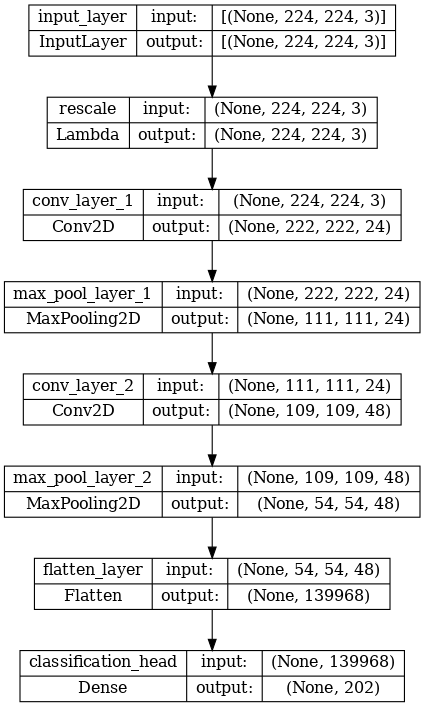

In [28]:
keras.utils.plot_model(model, show_shapes=True,dpi=80)

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


2025-04-30 10:54:49.401772: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:82: Filling up shuffle buffer (this may take a while): 59 of 1000
2025-04-30 10:55:09.404997: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:82: Filling up shuffle buffer (this may take a while): 177 of 1000
2025-04-30 10:55:19.426813: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:82: Filling up shuffle buffer (this may take a while): 234 of 1000
2025-04-30 10:55:22.707911: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


262/262 - 60s - loss: 5.1309 - f1_score: 0.0291 - f1_score_weighted: 0.0526 - val_loss: 4.5820 - val_f1_score: 0.0588 - val_f1_score_weighted: 0.0924 - lr: 9.9946e-04 - 60s/epoch - 230ms/step
Epoch 2/100
262/262 - 6s - loss: 3.5083 - f1_score: 0.3116 - f1_score_weighted: 0.3297 - val_loss: 4.7847 - val_f1_score: 0.1036 - val_f1_score_weighted: 0.1341 - lr: 9.9782e-04 - 6s/epoch - 23ms/step
Epoch 3/100
262/262 - 6s - loss: 1.8754 - f1_score: 0.8399 - f1_score_weighted: 0.8137 - val_loss: 5.1675 - val_f1_score: 0.1126 - val_f1_score_weighted: 0.1454 - lr: 9.9509e-04 - 6s/epoch - 23ms/step
Epoch 4/100
Restoring model weights from the end of the best epoch: 1.

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00033009483036585156.
262/262 - 6s - loss: 1.3859 - f1_score: 0.9452 - f1_score_weighted: 0.9330 - val_loss: 5.0280 - val_f1_score: 0.1092 - val_f1_score_weighted: 0.1498 - lr: 9.9128e-04 - 6s/epoch - 24ms/step
Epoch 4: early stopping


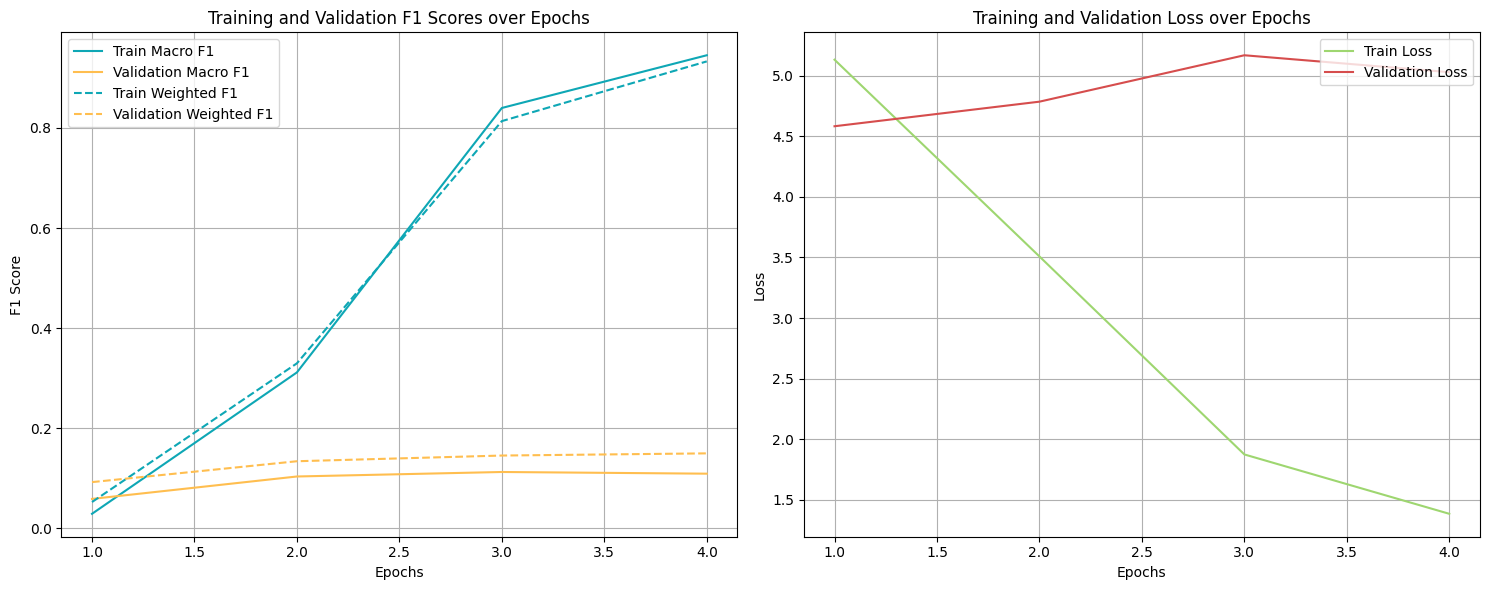

In [ ]:
plot_metrics(history)

> Performance on the training set is improving rapidly but validation f1 doesn't improve past 0.1. Clear sign of overfitting, as we can see as well we've got 28284826 parameters in total, mainly due to the flattening layer.

## Model 2

> We will try to use GlobalAveragePooling instead of fully connected layer.

In [29]:
def model_2(
    filter_1: int = 24,
    filter_2: int = 48,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:
    """
    GlobalAveragePooling instead of Flatten.
    """

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)
    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_2")

model = model_2()
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 24)      672       
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 24)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 48)      10416     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 48)        0         
 ng2D)                                                     

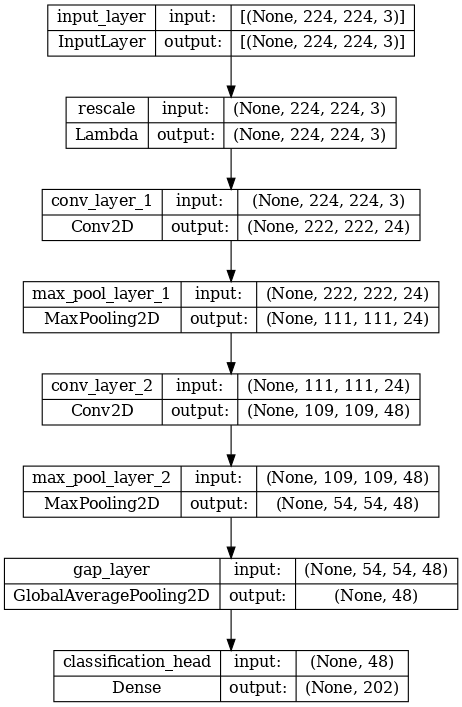

In [30]:
keras.utils.plot_model(model, show_shapes=True,dpi=80)

> We can easily see that the total number of parameters has gone down.

In [16]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


262/262 - 5s - loss: 5.1315 - f1_score: 0.0018 - f1_score_weighted: 0.0086 - val_loss: 5.0481 - val_f1_score: 0.0019 - val_f1_score_weighted: 0.0094 - lr: 9.9946e-04 - 5s/epoch - 20ms/step
Epoch 2/100
262/262 - 4s - loss: 5.0381 - f1_score: 0.0024 - f1_score_weighted: 0.0108 - val_loss: 4.9658 - val_f1_score: 0.0023 - val_f1_score_weighted: 0.0117 - lr: 9.9782e-04 - 4s/epoch - 17ms/step
Epoch 3/100
262/262 - 4s - loss: 4.9631 - f1_score: 0.0035 - f1_score_weighted: 0.0148 - val_loss: 4.9183 - val_f1_score: 0.0049 - val_f1_score_weighted: 0.0207 - lr: 9.9509e-04 - 4s/epoch - 17ms/step
Epoch 4/100
262/262 - 4s - loss: 4.9153 - f1_score: 0.0046 - f1_score_weighted: 0.0193 - val_loss: 4.8852 - val_f1_score: 0.0036 - val_f1_score_weighted: 0.0174 - lr: 9.9128e-04 - 4s/epoch - 17ms/step
Epoch 5/100
262/262 - 4s - loss: 4.8854 - f1_score: 0.0052 - f1_score_weighted: 0.0209 - val_loss: 4.8604 - val_f1_score: 0.0047 - val_f1_score_weighted: 0.0206 - lr: 9.8639e-04 - 4s/epoch - 17ms/step
Epoch 6

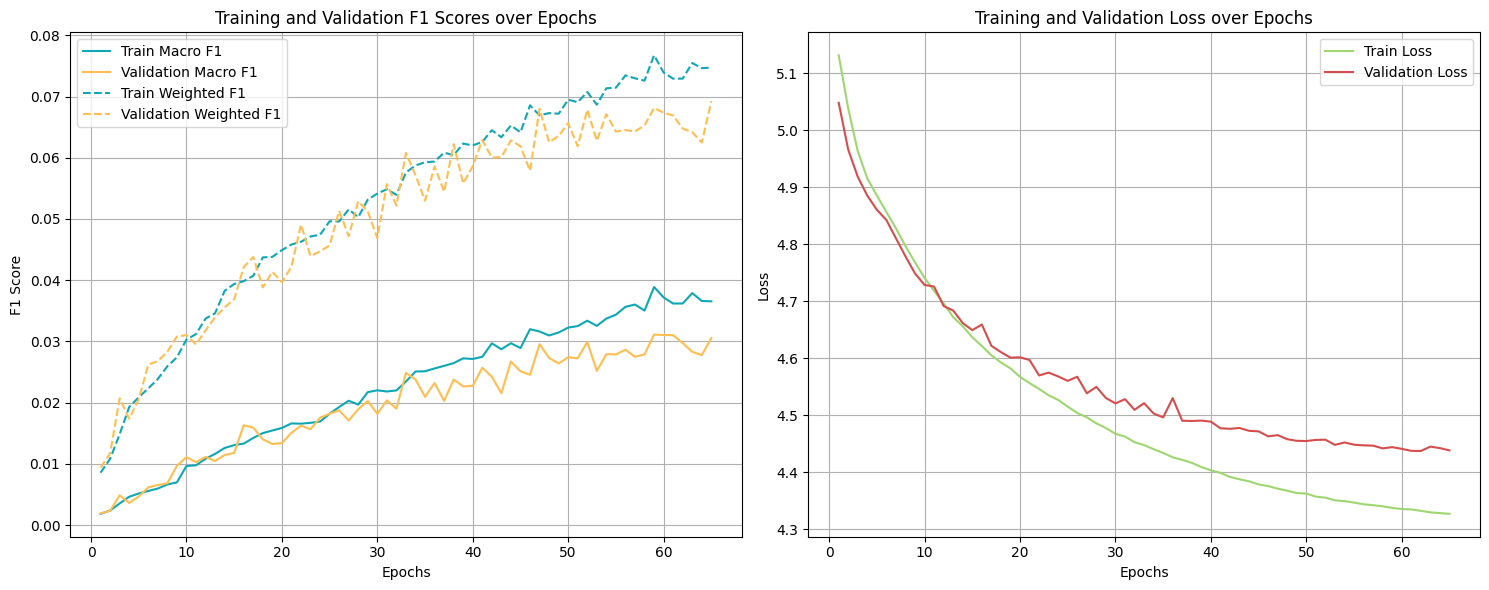

In [ ]:
plot_metrics(history)

> The F1 growth is much slower and steadier, but metrics do gradually improve. Much lower loss and less overfitting.

> It has smaller capacity, but better generalization. We will now increase the complexity of the model.

## Model 3

> Changing filters to 32, 64 instead of 24, 48

In [8]:
def model_3(
    filter_1: int = 32,
    filter_2: int = 64,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:
    """
    32, 64 filters instead of 24, 48
    """

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)
    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_3")


model = model_3()
model.summary()


Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 32)      896       
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 32)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 64)      18496     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 64)        0         
 ng2D)                                                     

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


2025-04-30 11:48:28.560627: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 57 of 1000
2025-04-30 11:48:48.523325: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 190 of 1000
2025-04-30 11:48:57.881502: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2025-04-30 11:48:57.935189: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-04-30 11:48:58.621469: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ff45e106160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-30 11:48:58.621508: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2025-04-30 11:48:58.627414: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] d

262/262 - 58s - loss: 5.1372 - f1_score: 0.0021 - f1_score_weighted: 0.0099 - val_loss: 5.0433 - val_f1_score: 0.0020 - val_f1_score_weighted: 0.0098 - lr: 9.9946e-04 - 58s/epoch - 221ms/step
Epoch 2/100
262/262 - 6s - loss: 5.0466 - f1_score: 0.0023 - f1_score_weighted: 0.0110 - val_loss: 4.9641 - val_f1_score: 0.0021 - val_f1_score_weighted: 0.0105 - lr: 9.9782e-04 - 6s/epoch - 21ms/step
Epoch 3/100
262/262 - 6s - loss: 4.9675 - f1_score: 0.0038 - f1_score_weighted: 0.0158 - val_loss: 4.9141 - val_f1_score: 0.0043 - val_f1_score_weighted: 0.0193 - lr: 9.9509e-04 - 6s/epoch - 21ms/step
Epoch 4/100
262/262 - 5s - loss: 4.9184 - f1_score: 0.0044 - f1_score_weighted: 0.0180 - val_loss: 4.8767 - val_f1_score: 0.0040 - val_f1_score_weighted: 0.0177 - lr: 9.9128e-04 - 5s/epoch - 21ms/step
Epoch 5/100
262/262 - 5s - loss: 4.8836 - f1_score: 0.0047 - f1_score_weighted: 0.0192 - val_loss: 4.8526 - val_f1_score: 0.0050 - val_f1_score_weighted: 0.0215 - lr: 9.8639e-04 - 5s/epoch - 21ms/step
Epoc

## Model 4

> Adding another convolutional layer

In [ ]:
def model_4(
    filter_1: int = 32,
    filter_2: int = 64,
    filter_3: int = 128,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)
    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_4")

model = model_4()
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 32)      896       
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 32)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 64)      18496     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 64)        0         
 ng2D)                                                     

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


262/262 - 8s - loss: 5.0949 - f1_score: 0.0023 - f1_score_weighted: 0.0110 - val_loss: 4.9595 - val_f1_score: 0.0044 - val_f1_score_weighted: 0.0203 - lr: 9.9946e-04 - 8s/epoch - 30ms/step
Epoch 2/100
262/262 - 6s - loss: 4.9442 - f1_score: 0.0046 - f1_score_weighted: 0.0191 - val_loss: 4.8694 - val_f1_score: 0.0045 - val_f1_score_weighted: 0.0214 - lr: 9.9782e-04 - 6s/epoch - 24ms/step
Epoch 3/100
262/262 - 6s - loss: 4.8588 - f1_score: 0.0062 - f1_score_weighted: 0.0253 - val_loss: 4.8020 - val_f1_score: 0.0060 - val_f1_score_weighted: 0.0267 - lr: 9.9509e-04 - 6s/epoch - 24ms/step
Epoch 4/100
262/262 - 6s - loss: 4.7810 - f1_score: 0.0079 - f1_score_weighted: 0.0288 - val_loss: 4.7209 - val_f1_score: 0.0087 - val_f1_score_weighted: 0.0335 - lr: 9.9128e-04 - 6s/epoch - 24ms/step
Epoch 5/100
262/262 - 6s - loss: 4.7203 - f1_score: 0.0108 - f1_score_weighted: 0.0348 - val_loss: 4.6899 - val_f1_score: 0.0109 - val_f1_score_weighted: 0.0359 - lr: 9.8639e-04 - 6s/epoch - 24ms/step
Epoch 6

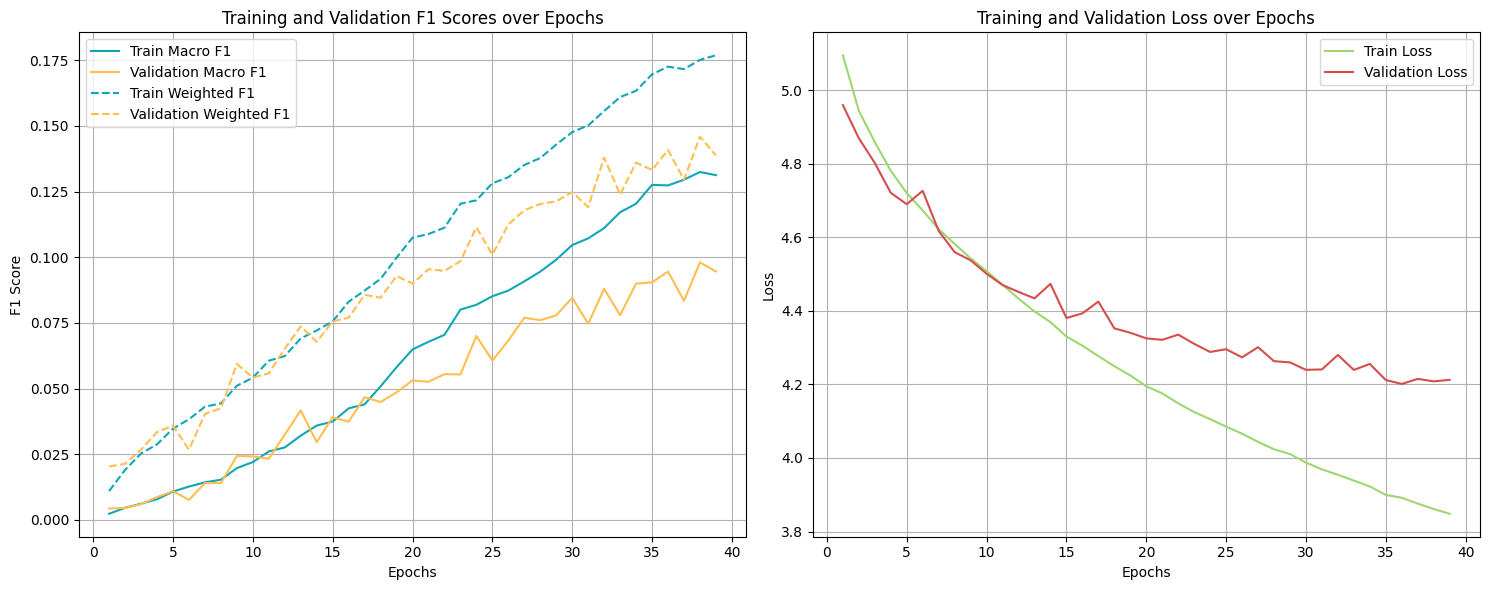

In [ ]:
plot_metrics(history)

> Slightly better.

## Model 5

In [10]:
def model_5(
    filter_1: int = 64,
    filter_2: int = 128,
    filter_3: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:


    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)
    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_5")

model = model_5()
model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 64)      1792      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 64)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 128)     73856     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 128)       0         
 ng2D)                                                     

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("2.2.3.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


262/262 - 18s - loss: 5.0884 - f1_score: 0.0027 - f1_score_weighted: 0.0120 - val_loss: 4.9457 - val_f1_score: 0.0022 - val_f1_score_weighted: 0.0105 - lr: 9.9946e-04 - 18s/epoch - 67ms/step
Epoch 2/100
262/262 - 12s - loss: 4.9259 - f1_score: 0.0054 - f1_score_weighted: 0.0211 - val_loss: 4.8363 - val_f1_score: 0.0045 - val_f1_score_weighted: 0.0200 - lr: 9.9782e-04 - 12s/epoch - 46ms/step
Epoch 3/100
262/262 - 12s - loss: 4.8324 - f1_score: 0.0080 - f1_score_weighted: 0.0277 - val_loss: 4.7561 - val_f1_score: 0.0082 - val_f1_score_weighted: 0.0312 - lr: 9.9509e-04 - 12s/epoch - 48ms/step
Epoch 4/100
262/262 - 12s - loss: 4.7393 - f1_score: 0.0097 - f1_score_weighted: 0.0317 - val_loss: 4.6952 - val_f1_score: 0.0101 - val_f1_score_weighted: 0.0309 - lr: 9.9128e-04 - 12s/epoch - 46ms/step
Epoch 5/100
262/262 - 12s - loss: 4.6771 - f1_score: 0.0130 - f1_score_weighted: 0.0388 - val_loss: 4.6123 - val_f1_score: 0.0149 - val_f1_score_weighted: 0.0437 - lr: 9.8639e-04 - 12s/epoch - 46ms/st

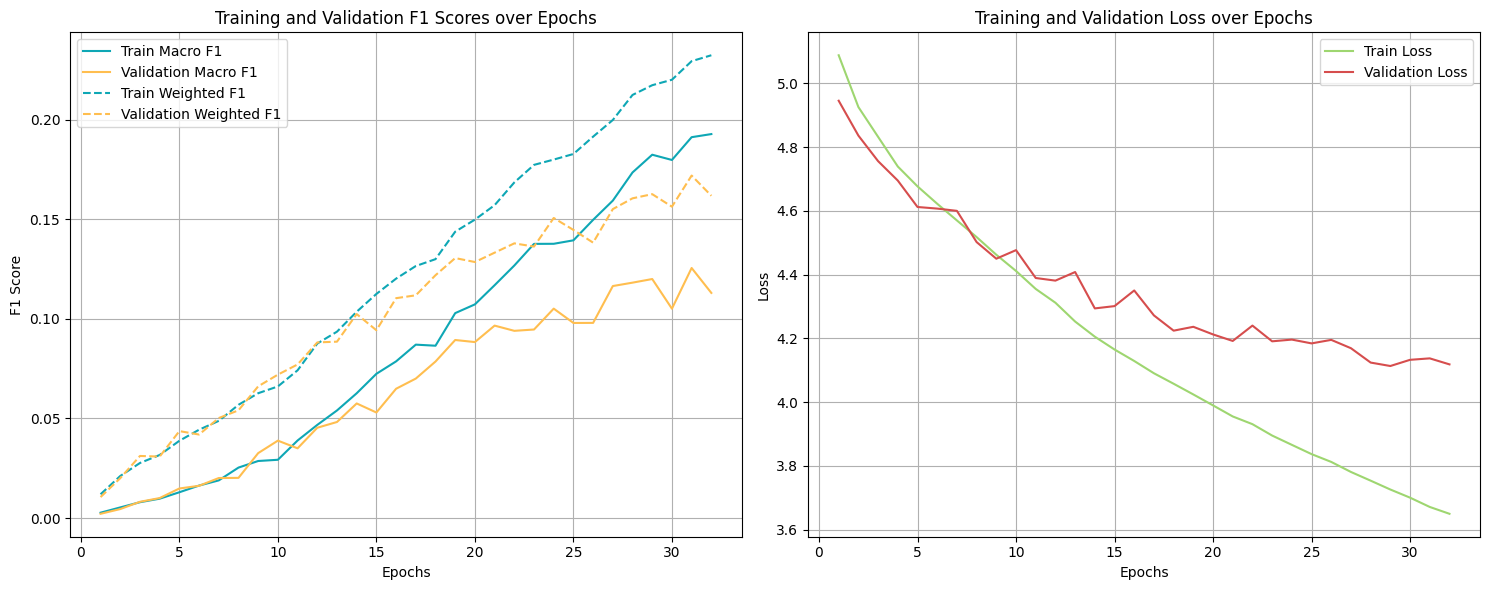

In [ ]:
plot_metrics(history)

## Model 6

> https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization

In [ ]:
def model_6(
    filter_1: int = 64,
    filter_2: int = 128,
    filter_3: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation=None, name="conv_layer_1")(x)
    x = BatchNormalization(name="batch_norm_1")(x)  
    x = Activation("relu", name="relu_1")(x)  
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_6")

model = model_6()
model.summary()


Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 64)      1792      
                                                                 
 batch_norm_1 (BatchNormali  (None, 222, 222, 64)      256       
 zation)                                                         
                                                                 
 relu_1 (Activation)         (None, 222, 222, 64)      0         
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 64)      0         
 ng2D)                                                     

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("2.3.1.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


262/262 - 18s - loss: 5.0140 - f1_score: 0.0056 - f1_score_weighted: 0.0210 - val_loss: 5.0819 - val_f1_score: 0.0067 - val_f1_score_weighted: 0.0247 - lr: 9.9946e-04 - 18s/epoch - 70ms/step
Epoch 2/100
262/262 - 16s - loss: 4.7846 - f1_score: 0.0107 - f1_score_weighted: 0.0360 - val_loss: 4.8297 - val_f1_score: 0.0059 - val_f1_score_weighted: 0.0248 - lr: 9.9782e-04 - 16s/epoch - 60ms/step
Epoch 3/100
262/262 - 16s - loss: 4.6334 - f1_score: 0.0190 - f1_score_weighted: 0.0489 - val_loss: 4.6212 - val_f1_score: 0.0171 - val_f1_score_weighted: 0.0481 - lr: 9.9509e-04 - 16s/epoch - 60ms/step
Epoch 4/100
262/262 - 16s - loss: 4.5116 - f1_score: 0.0286 - f1_score_weighted: 0.0633 - val_loss: 4.8837 - val_f1_score: 0.0178 - val_f1_score_weighted: 0.0473 - lr: 9.9128e-04 - 16s/epoch - 60ms/step
Epoch 5/100
262/262 - 16s - loss: 4.4049 - f1_score: 0.0386 - f1_score_weighted: 0.0759 - val_loss: 4.4903 - val_f1_score: 0.0295 - val_f1_score_weighted: 0.0685 - lr: 9.8639e-04 - 16s/epoch - 60ms/st

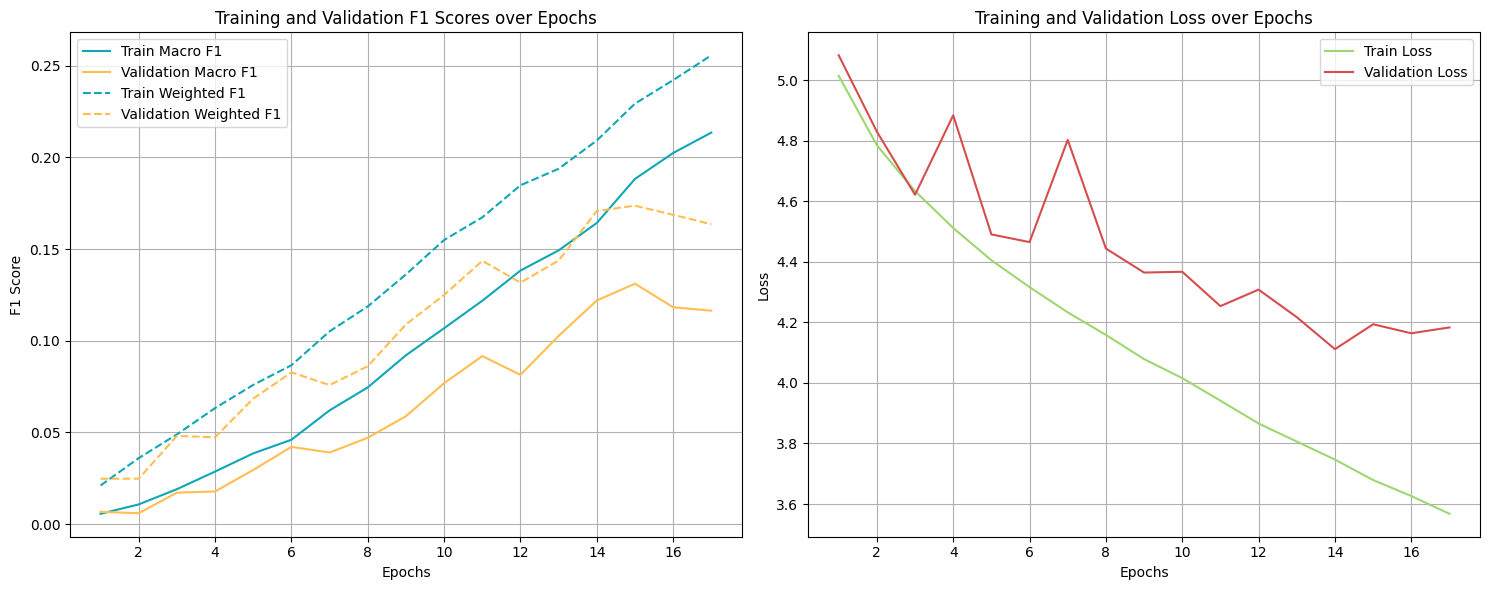

In [ ]:
plot_metrics(history)

## Model 7

In [ ]:
def model_7(
    filter_1: int = 64,
    filter_2: int = 128,
    filter_3: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:


    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation=None, name="conv_layer_1")(x)
    x = BatchNormalization(name="batch_norm_1")(x)  
    x = Activation("relu", name="relu_1")(x) 
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation=None, name="conv_layer_2")(x)
    x = BatchNormalization(name="batch_norm_2")(x)  
    x = Activation("relu", name="relu_2")(x) 
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation=None, name="conv_layer_3")(x)
    x = BatchNormalization(name="batch_norm_3")(x) 
    x = Activation("relu", name="relu_3")(x) 
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_7")

model = model_7()
model.summary()


Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 64)      1792      
                                                                 
 batch_norm_1 (BatchNormali  (None, 222, 222, 64)      256       
 zation)                                                         
                                                                 
 relu_1 (Activation)         (None, 222, 222, 64)      0         
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 64)      0         
 ng2D)                                                     

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("2.3.4.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


262/262 - 20s - loss: 4.9184 - f1_score: 0.0099 - f1_score_weighted: 0.0323 - val_loss: 5.1505 - val_f1_score: 0.0016 - val_f1_score_weighted: 0.0065 - lr: 9.9946e-04 - 20s/epoch - 76ms/step
Epoch 2/100
262/262 - 18s - loss: 4.6483 - f1_score: 0.0216 - f1_score_weighted: 0.0514 - val_loss: 4.8221 - val_f1_score: 0.0106 - val_f1_score_weighted: 0.0293 - lr: 9.9782e-04 - 18s/epoch - 70ms/step
Epoch 3/100
262/262 - 18s - loss: 4.5184 - f1_score: 0.0296 - f1_score_weighted: 0.0630 - val_loss: 4.6556 - val_f1_score: 0.0242 - val_f1_score_weighted: 0.0544 - lr: 9.9509e-04 - 18s/epoch - 70ms/step
Epoch 4/100
262/262 - 18s - loss: 4.4236 - f1_score: 0.0404 - f1_score_weighted: 0.0759 - val_loss: 4.4952 - val_f1_score: 0.0303 - val_f1_score_weighted: 0.0683 - lr: 9.9128e-04 - 18s/epoch - 71ms/step
Epoch 5/100
262/262 - 18s - loss: 4.3435 - f1_score: 0.0450 - f1_score_weighted: 0.0857 - val_loss: 4.8070 - val_f1_score: 0.0320 - val_f1_score_weighted: 0.0638 - lr: 9.8639e-04 - 18s/epoch - 70ms/st

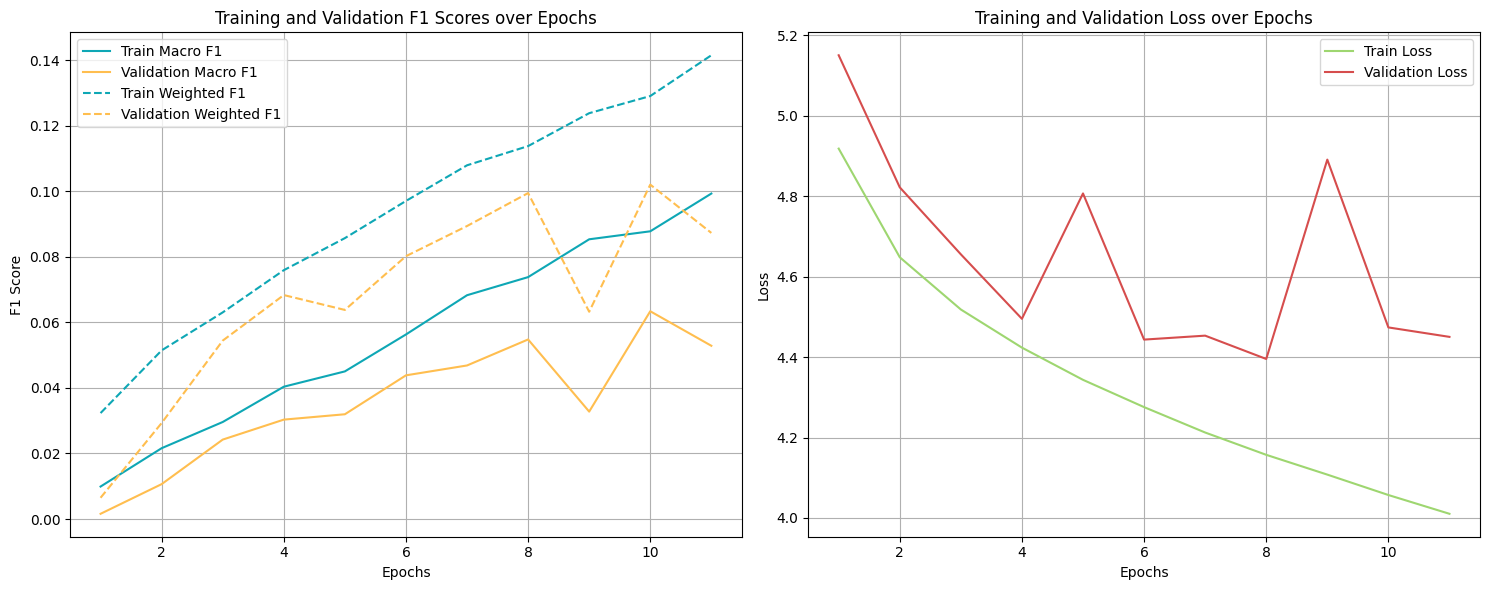

In [ ]:
plot_metrics(history)

> It didn't help at all but it's to be expected as it's usually applied to help stabilize training and helps with faster convergence. But mostly in deeper architectures, it's normal to not work here.

## Model 8

> https://www.ejece.org/index.php/ejece/article/view/596#title-5)

> Reccommended: apply dropout to dense layers, more prone to overfitting. We can also add to convolutional layers, but can interfer with the learning of spatial features.

In [13]:
def model_8(
    filter_1: int = 64,
    filter_2: int = 128,
    filter_3: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:
    """
    CNN with dropout only in the final layer.
    """
    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.4, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_8")

model = model_8()
model.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 64)      1792      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 64)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 128)     73856     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 128)       0         
 ng2D)                                                     

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3, restore_best_weights=True),
        keras.callbacks.CSVLogger("dropout_241.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


262/262 - 13s - loss: 5.1260 - f1_score: 0.0027 - f1_score_weighted: 0.0118 - val_loss: 4.9933 - val_f1_score: 0.0028 - val_f1_score_weighted: 0.0138 - lr: 9.9946e-04 - 13s/epoch - 51ms/step
Epoch 2/100
262/262 - 12s - loss: 4.9796 - f1_score: 0.0040 - f1_score_weighted: 0.0170 - val_loss: 4.8936 - val_f1_score: 0.0037 - val_f1_score_weighted: 0.0165 - lr: 9.9782e-04 - 12s/epoch - 45ms/step
Epoch 3/100
262/262 - 12s - loss: 4.8984 - f1_score: 0.0060 - f1_score_weighted: 0.0245 - val_loss: 4.8241 - val_f1_score: 0.0061 - val_f1_score_weighted: 0.0248 - lr: 9.9509e-04 - 12s/epoch - 45ms/step
Epoch 4/100
262/262 - 12s - loss: 4.8207 - f1_score: 0.0074 - f1_score_weighted: 0.0291 - val_loss: 4.7357 - val_f1_score: 0.0066 - val_f1_score_weighted: 0.0283 - lr: 9.9128e-04 - 12s/epoch - 45ms/step
Epoch 5/100
262/262 - 12s - loss: 4.7647 - f1_score: 0.0094 - f1_score_weighted: 0.0320 - val_loss: 4.7048 - val_f1_score: 0.0075 - val_f1_score_weighted: 0.0310 - lr: 9.8639e-04 - 12s/epoch - 46ms/st

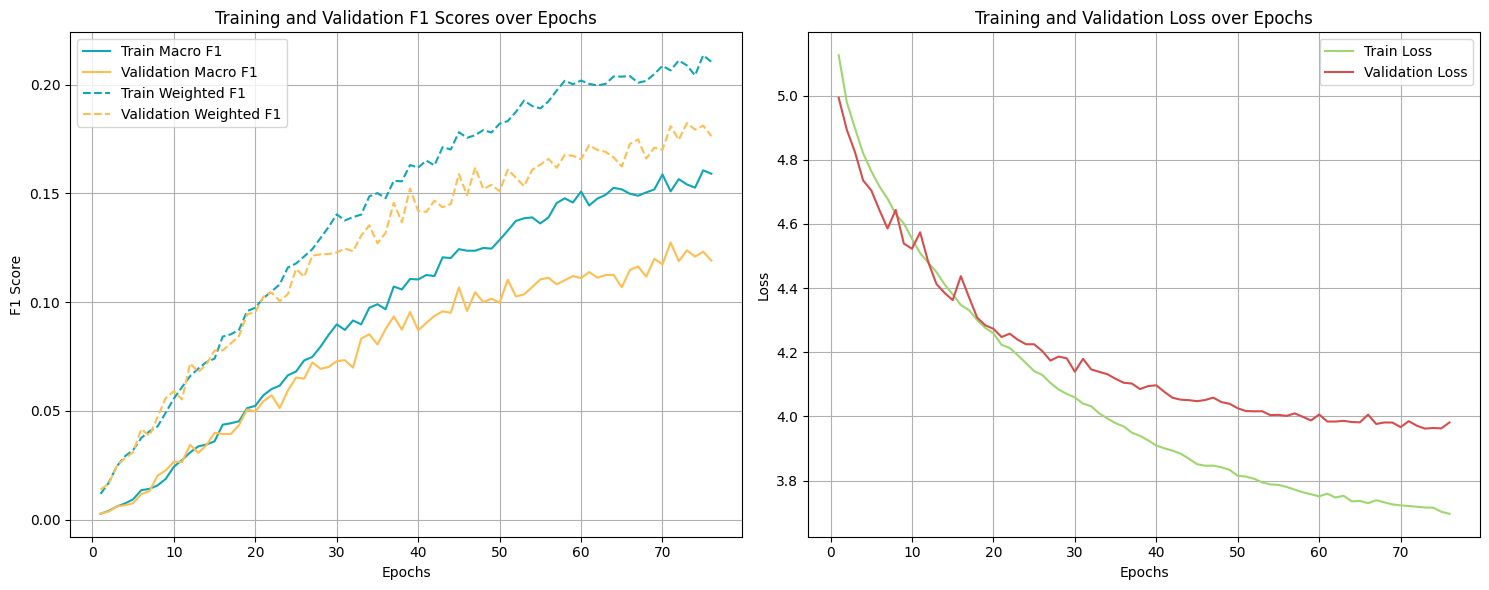

In [ ]:
plot_metrics(history)

## Model 9

> Dropout = 0.3

In [14]:
def model_9(
    filter_1: int = 64,
    filter_2: int = 128,
    filter_3: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.3, name="dropout_last")(x)# Dropout 

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_9")

model = model_9()
model.summary()

Model: "model_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 64)      1792      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 64)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 128)     73856     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 128)       0         
 ng2D)                                                     

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("2.4.2.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


262/262 - 13s - loss: 5.1117 - f1_score: 0.0028 - f1_score_weighted: 0.0119 - val_loss: 4.9706 - val_f1_score: 0.0035 - val_f1_score_weighted: 0.0155 - lr: 9.9946e-04 - 13s/epoch - 50ms/step
Epoch 2/100
262/262 - 12s - loss: 4.9833 - f1_score: 0.0039 - f1_score_weighted: 0.0166 - val_loss: 4.8851 - val_f1_score: 0.0031 - val_f1_score_weighted: 0.0153 - lr: 9.9782e-04 - 12s/epoch - 47ms/step
Epoch 3/100
262/262 - 12s - loss: 4.9091 - f1_score: 0.0054 - f1_score_weighted: 0.0220 - val_loss: 4.9049 - val_f1_score: 0.0058 - val_f1_score_weighted: 0.0255 - lr: 9.9509e-04 - 12s/epoch - 46ms/step
Epoch 4/100
262/262 - 12s - loss: 4.8315 - f1_score: 0.0076 - f1_score_weighted: 0.0294 - val_loss: 4.7322 - val_f1_score: 0.0071 - val_f1_score_weighted: 0.0297 - lr: 9.9128e-04 - 12s/epoch - 47ms/step
Epoch 5/100
262/262 - 12s - loss: 4.7644 - f1_score: 0.0101 - f1_score_weighted: 0.0322 - val_loss: 4.6948 - val_f1_score: 0.0120 - val_f1_score_weighted: 0.0348 - lr: 9.8639e-04 - 12s/epoch - 46ms/st

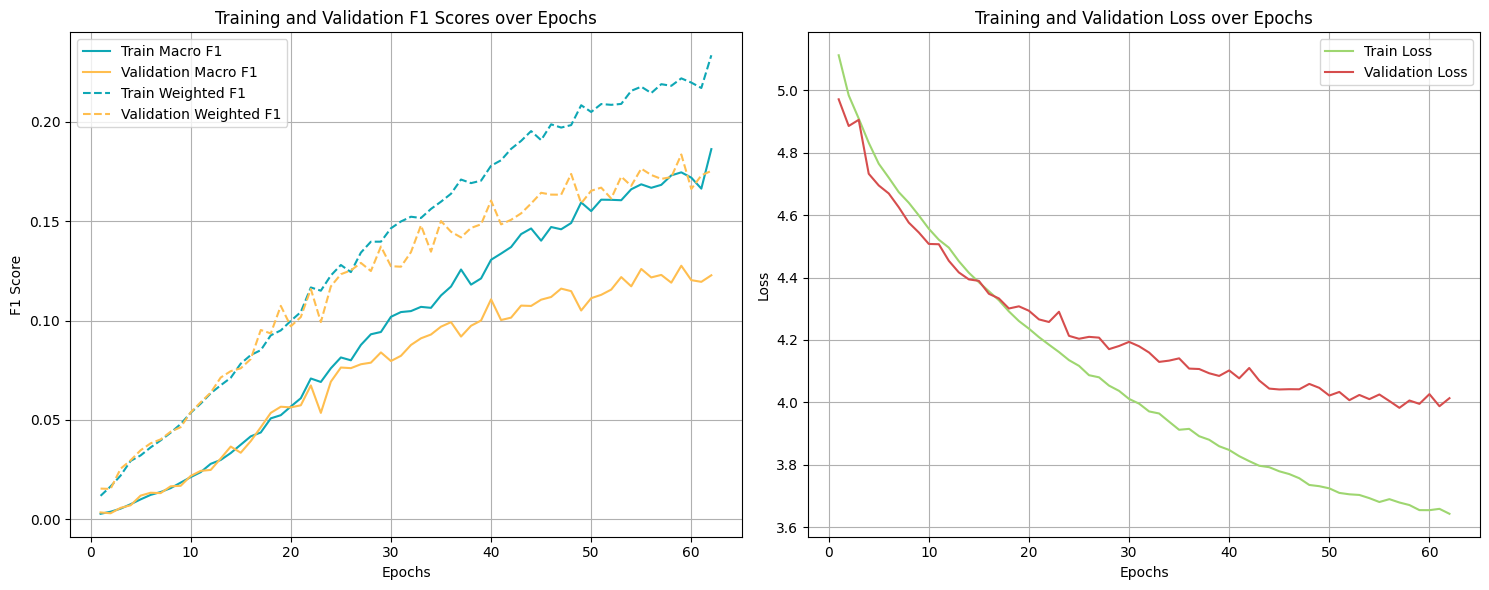

In [ ]:
plot_metrics(history)

## Model 10

> Dropout 0.25

In [15]:
def model_10(
    filter_1: int = 64,
    filter_2: int = 128,
    filter_3: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.25, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_10")

model = model_10()
model.summary()

Model: "model_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 64)      1792      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 64)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 128)     73856     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 128)       0         
 ng2D)                                                    

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("2.4.2.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100
262/262 - 14s - loss: 5.1108 - f1_score: 0.0021 - f1_score_weighted: 0.0097 - val_loss: 4.9559 - val_f1_score: 0.0028 - val_f1_score_weighted: 0.0138 - lr: 9.9946e-04 - 14s/epoch - 52ms/step
Epoch 2/100
262/262 - 12s - loss: 4.9620 - f1_score: 0.0041 - f1_score_weighted: 0.0179 - val_loss: 4.8655 - val_f1_score: 0.0048 - val_f1_score_weighted: 0.0208 - lr: 9.9782e-04 - 12s/epoch - 47ms/step
Epoch 3/100
262/262 - 13s - loss: 4.8763 - f1_score: 0.0064 - f1_score_weighted: 0.0254 - val_loss: 4.7998 - val_f1_score: 0.0070 - val_f1_score_weighted: 0.0286 - lr: 9.9509e-04 - 13s/epoch - 48ms/step
Epoch 4/100
262/262 - 12s - loss: 4.7964 - f1_score: 0.0069 - f1_score_weighted: 0.0277 - val_loss: 4.7496 - val_f1_score: 0.0077 - val_f1_score_weighted: 0.0312 - lr: 9.9128e-04 - 12s/epoch - 47ms/step
Epoch 5/100
262/262 - 13s - loss: 4.7297 - f1_score: 0.0103 - f1_score_weighted: 0.0355 - val_loss: 4.6572 - val_f1_score: 0.0097 - val_f1_score_weighted: 0.0378 - lr: 9.8639e-04 - 13s/epo

## Model 11

> Adding another conv layer

In [16]:
def model_11(
    filter_1: int = 32,
    filter_2: int = 64,
    filter_3: int = 128,
    filter_4: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = Conv2D(filters=filter_4, kernel_size=kernel_size, activation="relu", name="conv_layer_4")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_4")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.3, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_11")

model = model_11()
model.summary()

Model: "model_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 32)      896       
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 111, 111, 32)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 109, 109, 64)      18496     
                                                                 
 max_pool_layer_2 (MaxPooli  (None, 54, 54, 64)        0         
 ng2D)                                                    

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100
262/262 - 9s - loss: 5.1264 - f1_score: 0.0018 - f1_score_weighted: 0.0080 - val_loss: 5.0130 - val_f1_score: 0.0023 - val_f1_score_weighted: 0.0117 - lr: 9.9946e-04 - 9s/epoch - 33ms/step
Epoch 2/100
262/262 - 7s - loss: 4.9963 - f1_score: 0.0036 - f1_score_weighted: 0.0162 - val_loss: 4.8791 - val_f1_score: 0.0035 - val_f1_score_weighted: 0.0174 - lr: 9.9782e-04 - 7s/epoch - 27ms/step
Epoch 3/100
262/262 - 7s - loss: 4.8745 - f1_score: 0.0061 - f1_score_weighted: 0.0247 - val_loss: 4.7685 - val_f1_score: 0.0070 - val_f1_score_weighted: 0.0283 - lr: 9.9509e-04 - 7s/epoch - 27ms/step
Epoch 4/100
262/262 - 7s - loss: 4.7797 - f1_score: 0.0088 - f1_score_weighted: 0.0311 - val_loss: 4.6665 - val_f1_score: 0.0111 - val_f1_score_weighted: 0.0381 - lr: 9.9128e-04 - 7s/epoch - 26ms/step
Epoch 5/100
262/262 - 8s - loss: 4.7120 - f1_score: 0.0112 - f1_score_weighted: 0.0362 - val_loss: 4.6271 - val_f1_score: 0.0152 - val_f1_score_weighted: 0.0462 - lr: 9.8639e-04 - 8s/epoch - 29ms/

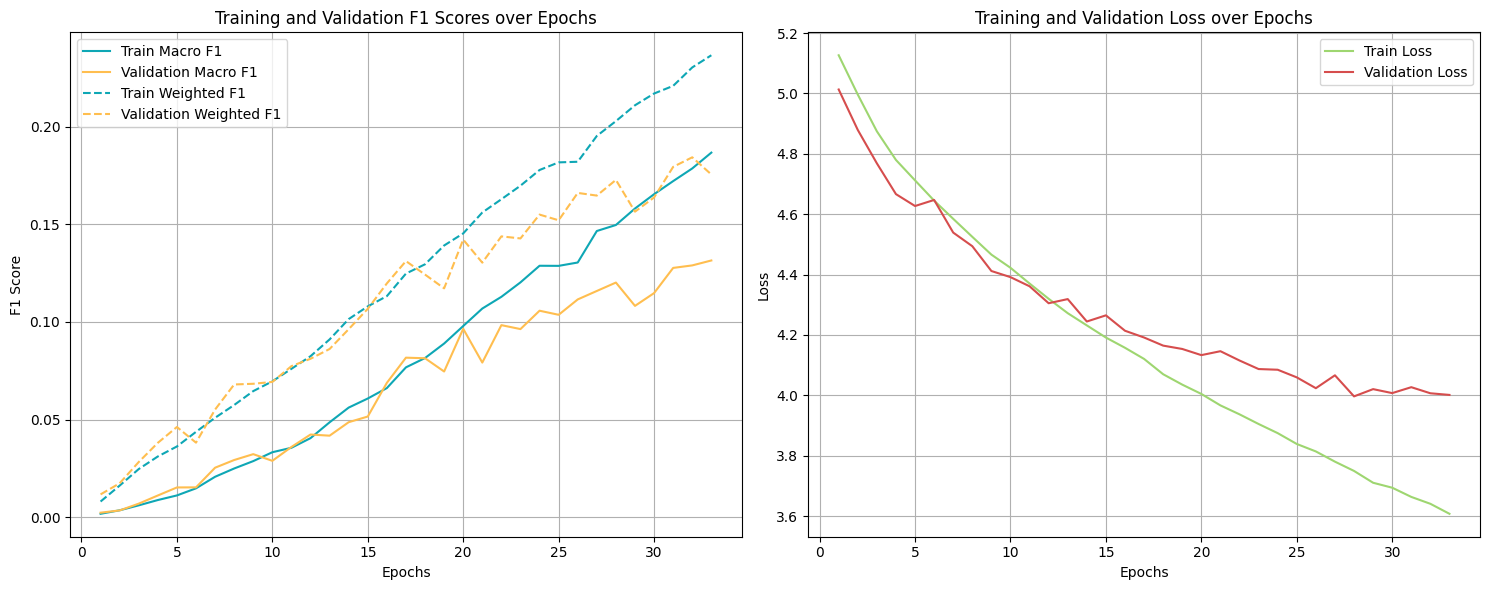

In [ ]:
plot_metrics(history)

## Model 12

> Trying a more gradual increase - two 32 filters. First learn simple features and then have a second layer to refine, before moving to more complex laers.

> Less risk of overfitting

In [17]:
def model_12(
    filter_1: int = 32,
    filter_2: int = 64,
    filter_3: int = 128,
    filter_4: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:
    """
    32 32 max 64 max 128 max 256 max
    """
    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1.2")(x) # added this
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = Conv2D(filters=filter_4, kernel_size=kernel_size, activation="relu", name="conv_layer_4")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_4")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.3, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_12")

model = model_12()
model.summary()

Model: "model_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 32)      896       
                                                                 
 conv_layer_1.2 (Conv2D)     (None, 220, 220, 32)      9248      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 110, 110, 32)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 108, 108, 64)      18496     
                                                          

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100
262/262 - 16s - loss: 5.1395 - f1_score: 0.0021 - f1_score_weighted: 0.0097 - val_loss: 5.0244 - val_f1_score: 0.0024 - val_f1_score_weighted: 0.0121 - lr: 9.9946e-04 - 16s/epoch - 61ms/step
Epoch 2/100
262/262 - 11s - loss: 5.0103 - f1_score: 0.0030 - f1_score_weighted: 0.0128 - val_loss: 4.9069 - val_f1_score: 0.0037 - val_f1_score_weighted: 0.0158 - lr: 9.9782e-04 - 11s/epoch - 41ms/step
Epoch 3/100
262/262 - 11s - loss: 4.9295 - f1_score: 0.0042 - f1_score_weighted: 0.0179 - val_loss: 5.0105 - val_f1_score: 0.0036 - val_f1_score_weighted: 0.0173 - lr: 9.9509e-04 - 11s/epoch - 42ms/step
Epoch 4/100
262/262 - 11s - loss: 4.8655 - f1_score: 0.0053 - f1_score_weighted: 0.0216 - val_loss: 4.8352 - val_f1_score: 0.0048 - val_f1_score_weighted: 0.0201 - lr: 9.9128e-04 - 11s/epoch - 42ms/step
Epoch 5/100
262/262 - 11s - loss: 4.8114 - f1_score: 0.0072 - f1_score_weighted: 0.0278 - val_loss: 4.7592 - val_f1_score: 0.0092 - val_f1_score_weighted: 0.0362 - lr: 9.8639e-04 - 11s/epo

> It helped a lot! F1 0.2

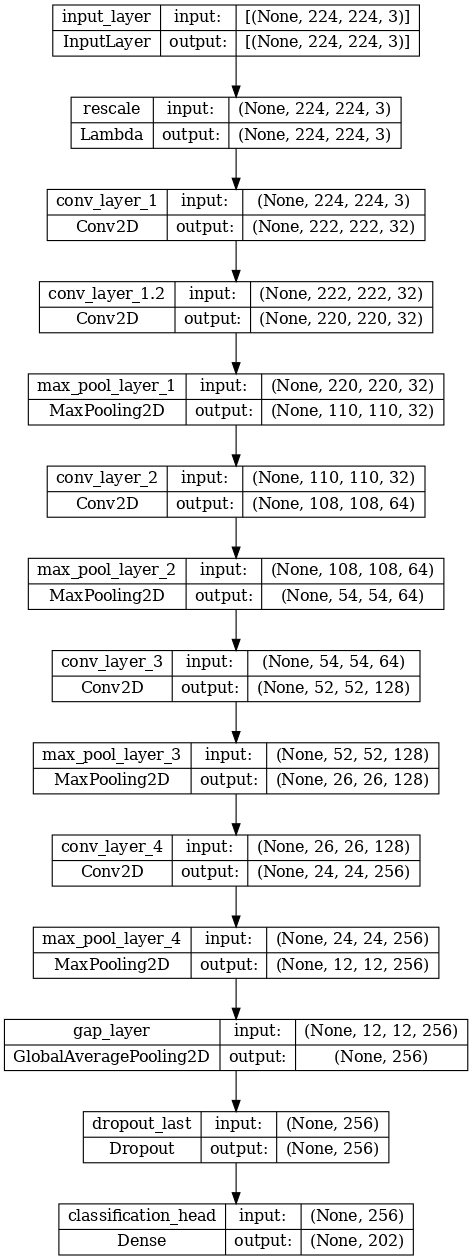

In [33]:
keras.utils.plot_model(model, show_shapes=True,dpi=80)

## Model 13

In [18]:
def model_13(
    filter_1: int = 32,
    filter_2: int = 64,
    filter_3: int = 128,
    filter_4: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:
    """
    32 32 max 64 64 max 128 max 
    """
    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1.1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)
    x = Dropout(0.1, name="dropout_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)
    x = Dropout(0.1, name="dropout_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)
    x = Dropout(0.1, name="dropout_3")(x)

    x = Conv2D(filters=filter_4, kernel_size=kernel_size, activation="relu", name="conv_layer_4")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_4")(x)
    x = Dropout(0.1, name="dropout_4")(x)


    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.3, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_13")

model = model_13()
model.summary()

Model: "model_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 32)      896       
                                                                 
 conv_layer_1.1 (Conv2D)     (None, 220, 220, 32)      9248      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 110, 110, 32)      0         
 ng2D)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 110, 110, 32)      0         
                                                          

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100


2025-04-30 15:04:36.263564: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inour_cnn/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


262/262 - 28s - loss: 5.1176 - f1_score: 0.0022 - f1_score_weighted: 0.0098 - val_loss: 5.0032 - val_f1_score: 0.0021 - val_f1_score_weighted: 0.0103 - lr: 9.9946e-04 - 28s/epoch - 107ms/step
Epoch 2/100
262/262 - 14s - loss: 5.0017 - f1_score: 0.0039 - f1_score_weighted: 0.0157 - val_loss: 4.9236 - val_f1_score: 0.0049 - val_f1_score_weighted: 0.0212 - lr: 9.9782e-04 - 14s/epoch - 52ms/step
Epoch 3/100
262/262 - 14s - loss: 4.9199 - f1_score: 0.0050 - f1_score_weighted: 0.0208 - val_loss: 4.8540 - val_f1_score: 0.0065 - val_f1_score_weighted: 0.0292 - lr: 9.9509e-04 - 14s/epoch - 53ms/step
Epoch 4/100
262/262 - 14s - loss: 4.8318 - f1_score: 0.0087 - f1_score_weighted: 0.0291 - val_loss: 4.7528 - val_f1_score: 0.0075 - val_f1_score_weighted: 0.0317 - lr: 9.9128e-04 - 14s/epoch - 53ms/step
Epoch 5/100
262/262 - 14s - loss: 4.7565 - f1_score: 0.0113 - f1_score_weighted: 0.0338 - val_loss: 4.7133 - val_f1_score: 0.0109 - val_f1_score_weighted: 0.0346 - lr: 9.8639e-04 - 14s/epoch - 55ms/s

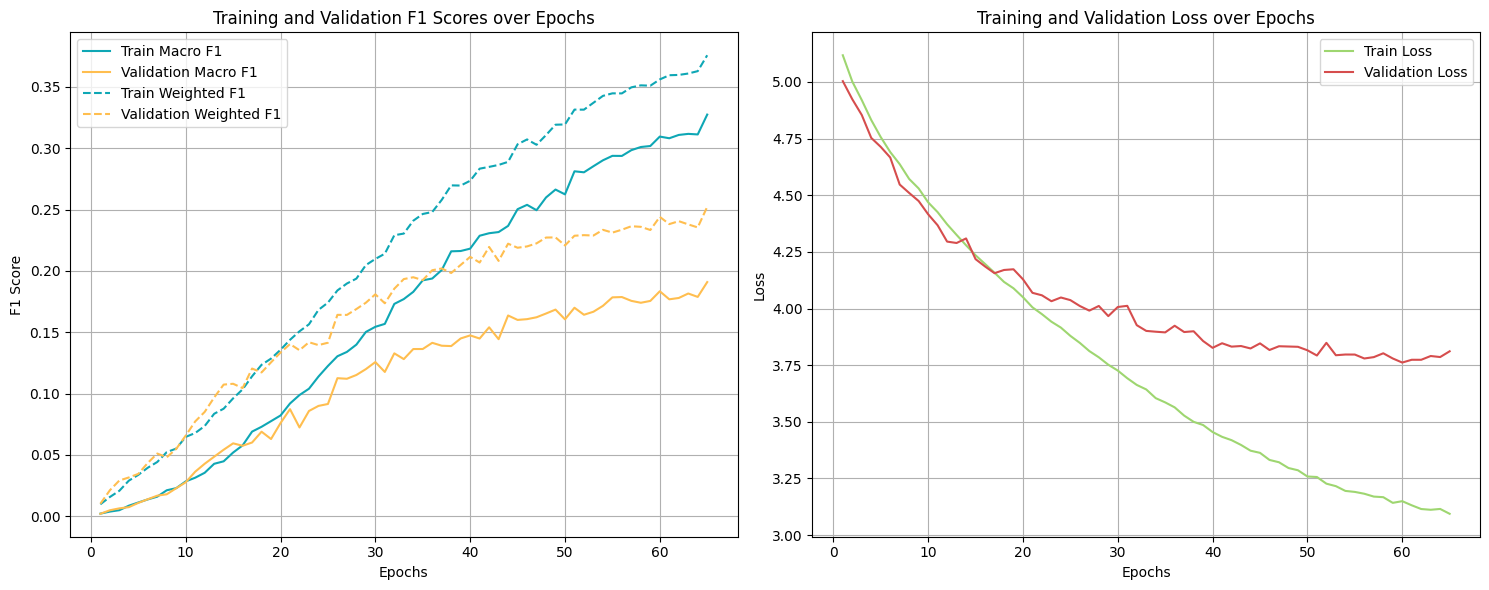

In [ ]:
plot_metrics(history)

## Model 14

In [19]:
def model_14(
    filter_1: int = 32,
    filter_2: int = 64,
    filter_3: int = 128,
    filter_4: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:
    """
    dropout 0.1 early
    """
    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", padding="same", name="conv_layer_1")(x)
    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", padding="same", name="conv_layer_1.2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", padding="same", name="conv_layer_2")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", padding="same", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = Conv2D(filters=filter_4, kernel_size=kernel_size, activation="relu", padding="same", name="conv_layer_4")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_4")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)
    
    x = Dense(256, activation="relu", name="dense_1")(x)
    x = Dropout(0.3, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_14")

model = model_14()
model.summary()

Model: "model_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 224, 224, 32)      896       
                                                                 
 conv_layer_1.2 (Conv2D)     (None, 224, 224, 32)      9248      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 112, 112, 32)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 112, 112, 64)      18496     
                                                          

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100
262/262 - 23s - loss: 5.1426 - f1_score: 0.0016 - f1_score_weighted: 0.0072 - val_loss: 5.0507 - val_f1_score: 0.0010 - val_f1_score_weighted: 0.0054 - lr: 9.9946e-04 - 23s/epoch - 88ms/step
Epoch 2/100
262/262 - 21s - loss: 5.0669 - f1_score: 0.0018 - f1_score_weighted: 0.0084 - val_loss: 4.9729 - val_f1_score: 0.0020 - val_f1_score_weighted: 0.0099 - lr: 9.9782e-04 - 21s/epoch - 79ms/step
Epoch 3/100
262/262 - 21s - loss: 4.9809 - f1_score: 0.0026 - f1_score_weighted: 0.0123 - val_loss: 4.9432 - val_f1_score: 0.0024 - val_f1_score_weighted: 0.0121 - lr: 9.9509e-04 - 21s/epoch - 79ms/step
Epoch 4/100
262/262 - 21s - loss: 4.9155 - f1_score: 0.0039 - f1_score_weighted: 0.0173 - val_loss: 4.8684 - val_f1_score: 0.0057 - val_f1_score_weighted: 0.0225 - lr: 9.9128e-04 - 21s/epoch - 79ms/step
Epoch 5/100
262/262 - 21s - loss: 4.8520 - f1_score: 0.0060 - f1_score_weighted: 0.0248 - val_loss: 4.8284 - val_f1_score: 0.0061 - val_f1_score_weighted: 0.0272 - lr: 9.8639e-04 - 21s/epo

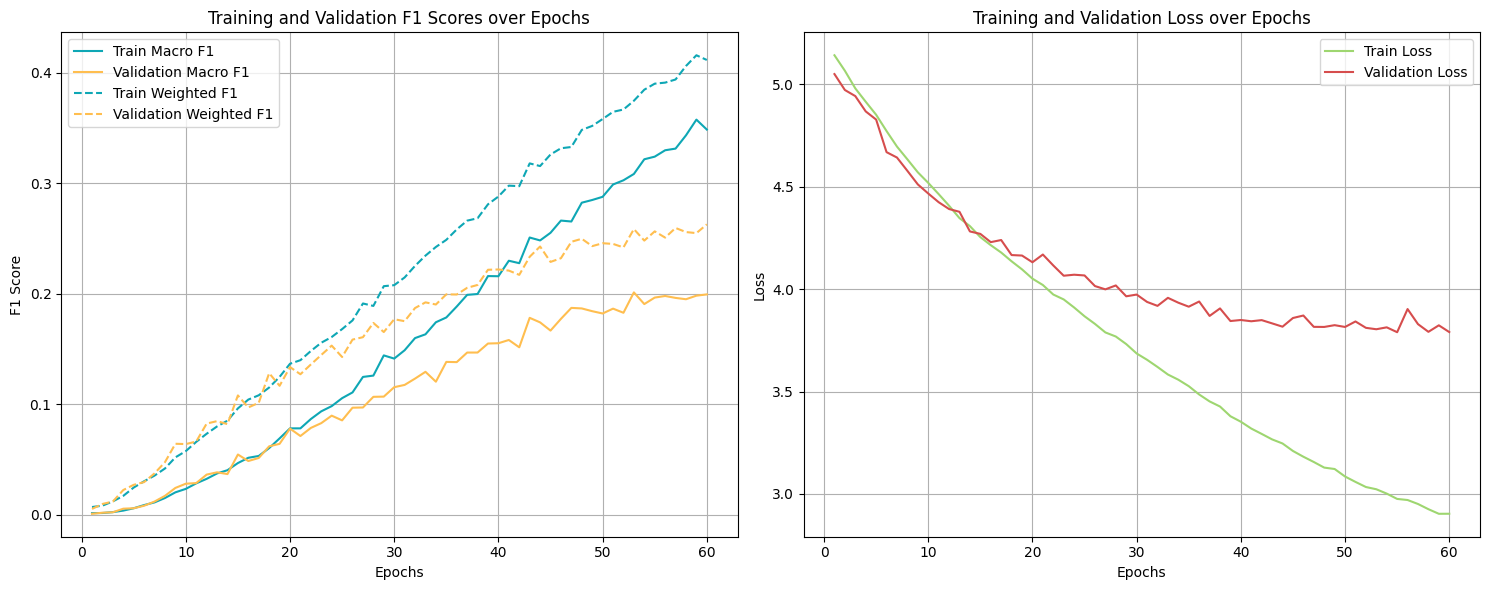

In [ ]:
plot_metrics(history)

## Model 15

In [ ]:
def model_15(
    filter_1: int = 32,
    filter_2: int = 64,
    filter_3: int = 128,
    filter_4: int = 256,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1.1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2.1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = Conv2D(filters=filter_4, kernel_size=kernel_size, activation="relu", name="conv_layer_4")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_4")(x)

    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.3, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_15")

model = model_15()
model.summary()

Model: "model_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 32)      896       
                                                                 
 conv_layer_1.1 (Conv2D)     (None, 220, 220, 32)      9248      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 110, 110, 32)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 108, 108, 64)      18496     
                                                          

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100
262/262 - 16s - loss: 5.1466 - f1_score: 0.0018 - f1_score_weighted: 0.0078 - val_loss: 5.0513 - val_f1_score: 2.5200e-04 - val_f1_score_weighted: 0.0013 - lr: 9.9946e-04 - 16s/epoch - 61ms/step
Epoch 2/100
262/262 - 13s - loss: 5.0822 - f1_score: 0.0018 - f1_score_weighted: 0.0084 - val_loss: 4.9834 - val_f1_score: 0.0012 - val_f1_score_weighted: 0.0061 - lr: 9.9782e-04 - 13s/epoch - 48ms/step
Epoch 3/100
262/262 - 13s - loss: 5.0163 - f1_score: 0.0016 - f1_score_weighted: 0.0076 - val_loss: 4.9614 - val_f1_score: 0.0018 - val_f1_score_weighted: 0.0088 - lr: 9.9509e-04 - 13s/epoch - 49ms/step
Epoch 4/100
262/262 - 13s - loss: 4.9750 - f1_score: 0.0025 - f1_score_weighted: 0.0121 - val_loss: 4.9058 - val_f1_score: 0.0030 - val_f1_score_weighted: 0.0151 - lr: 9.9128e-04 - 13s/epoch - 48ms/step
Epoch 5/100
262/262 - 13s - loss: 4.9246 - f1_score: 0.0037 - f1_score_weighted: 0.0163 - val_loss: 4.8370 - val_f1_score: 0.0046 - val_f1_score_weighted: 0.0208 - lr: 9.8639e-04 - 13s

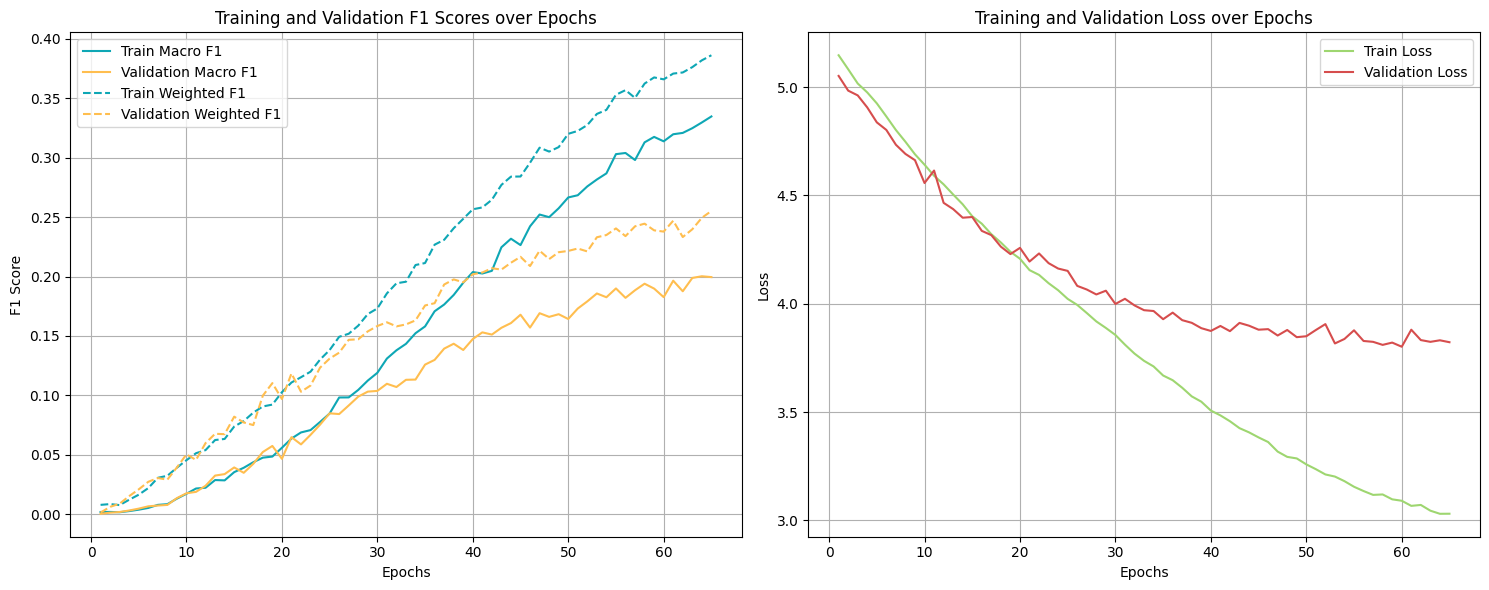

In [ ]:
plot_metrics(history)

## Model 16

In [ ]:
def model_16(
    filter_1: int = 32,
    filter_2: int = 64,
    filter_3: int = 128,
    filter_4: int = 256,
    filter_5: int = 512,
    kernel_size: tuple = (3, 3), 
    pool_size: tuple = (2, 2),
) -> Model:

    inputs = Input(shape=(224, 224, 3), name="input_layer")
    x = Lambda(lambda x: x / 255.0, name="rescale")(inputs)

    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1")(x)
    x = Conv2D(filters=filter_1, kernel_size=kernel_size, activation="relu", name="conv_layer_1.1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_1")(x)

    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2")(x)
    x = Conv2D(filters=filter_2, kernel_size=kernel_size, activation="relu", name="conv_layer_2.1")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_2")(x)

    x = Conv2D(filters=filter_3, kernel_size=kernel_size, activation="relu", name="conv_layer_3")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_3")(x)

    x = Conv2D(filters=filter_4, kernel_size=kernel_size, activation="relu", name="conv_layer_4")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_4")(x)

    # Another layer
    x = Conv2D(filters=filter_5, kernel_size=kernel_size, activation="relu", name="conv_layer_5")(x)
    x = MaxPooling2D(pool_size=pool_size, name="max_pool_layer_5")(x)


    x = GlobalAveragePooling2D(name="gap_layer")(x)

    x = Dropout(0.3, name="dropout_last")(x)

    outputs = Dense(202, activation="softmax", name="classification_head")(x)

    return Model(inputs=inputs, outputs=outputs, name="model_16")

model = model_16()
model.summary()

Model: "model_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 rescale (Lambda)            (None, 224, 224, 3)       0         
                                                                 
 conv_layer_1 (Conv2D)       (None, 222, 222, 32)      896       
                                                                 
 conv_layer_1.1 (Conv2D)     (None, 220, 220, 32)      9248      
                                                                 
 max_pool_layer_1 (MaxPooli  (None, 110, 110, 32)      0         
 ng2D)                                                           
                                                                 
 conv_layer_2 (Conv2D)       (None, 108, 108, 64)      18496     
                                                          

In [ ]:
model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, len(train_ds) * 100 * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalFocalCrossentropy",
    label_smoothing=0.1,
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.F1Score(average="weighted", name="f1_score_weighted")],  
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        keras.callbacks.CSVLogger("metrics.csv"),
        keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, min_delta=0.002, factor=0.333, verbose=1) 
        ],
    verbose=2
)

Epoch 1/100
262/262 - 15s - loss: 1.2684 - f1_score: 0.0020 - f1_score_weighted: 0.0070 - val_loss: 1.2447 - val_f1_score: 2.2464e-04 - val_f1_score_weighted: 0.0011 - lr: 9.9946e-04 - 15s/epoch - 55ms/step
Epoch 2/100
262/262 - 13s - loss: 1.2556 - f1_score: 0.0012 - f1_score_weighted: 0.0059 - val_loss: 1.2458 - val_f1_score: 7.4450e-04 - val_f1_score_weighted: 0.0039 - lr: 9.9782e-04 - 13s/epoch - 49ms/step
Epoch 3/100
262/262 - 13s - loss: 1.2443 - f1_score: 0.0016 - f1_score_weighted: 0.0079 - val_loss: 1.2265 - val_f1_score: 0.0012 - val_f1_score_weighted: 0.0062 - lr: 9.9509e-04 - 13s/epoch - 49ms/step
Epoch 4/100
262/262 - 13s - loss: 1.2298 - f1_score: 0.0022 - f1_score_weighted: 0.0103 - val_loss: 1.2112 - val_f1_score: 0.0020 - val_f1_score_weighted: 0.0101 - lr: 9.9128e-04 - 13s/epoch - 49ms/step
Epoch 5/100
262/262 - 13s - loss: 1.2200 - f1_score: 0.0027 - f1_score_weighted: 0.0124 - val_loss: 1.2050 - val_f1_score: 0.0019 - val_f1_score_weighted: 0.0097 - lr: 9.8639e-04 -